# Assumptions

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.937
Model:                            OLS   Adj. R-squared:                  0.935
Method:                 Least Squares   F-statistic:                     479.0
Date:                Sat, 20 Jun 2026   Prob (F-statistic):           1.33e-57
Time:                        11:59:12   Log-Likelihood:                -207.06
No. Observations:                 100   AIC:                             422.1
Df Residuals:                      96   BIC:                             432.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.4700      0.617      7.251      0.0

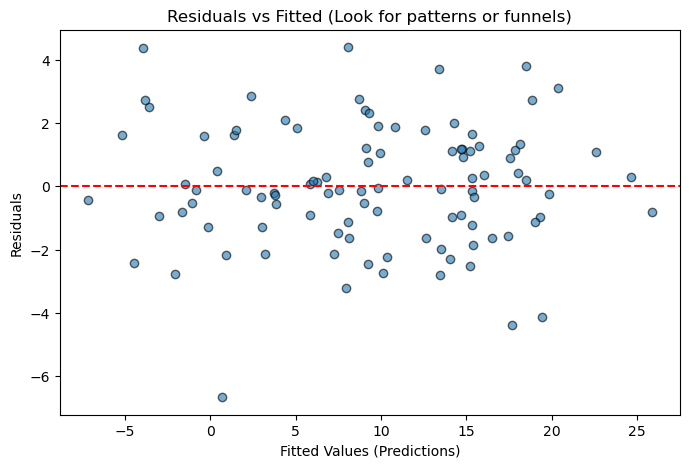


Variance Inflation Factors:
   Feature       VIF
0   const  9.910762
1      X1  1.010798
2      X2  1.002955
3      X3  1.008145


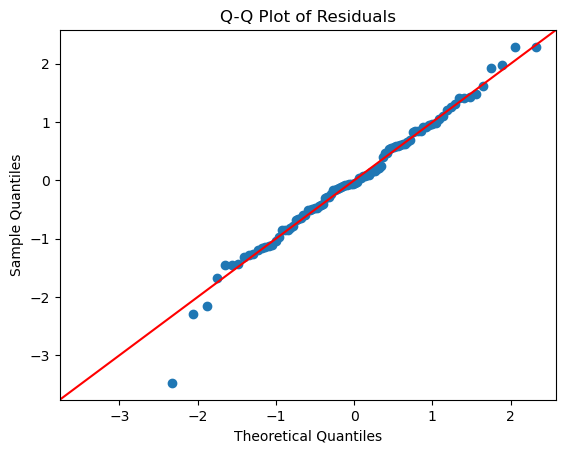

In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt

# 1. Generate Synthetic Data
np.random.seed(42)
X_data = np.random.rand(100, 3) * 10
# Y = 5 + 2*X1 - 1.5*X2 + 0.5*X3 + Noise
y = 5 + 2*X_data[:, 0] - 1.5*X_data[:, 1] + 0.5*X_data[:, 2] + np.random.randn(100) * 2

# Build DataFrame and add constant for intercept
df = pd.DataFrame(X_data, columns=['X1', 'X2', 'X3'])
X_design = sm.add_constant(df)

# 2. Fit the Model
model = sm.OLS(y, X_design).fit()
print(model.summary()) # Prints R-squared, P-values, Durbin-Watson, etc.

# 3. Extract Residuals and Fitted Values
fitted_vals = model.predict(X_design)
residuals = model.resid

# ==========================================
# DIAGNOSTIC 1 & 3: Linearity & Homoscedasticity
# ==========================================
plt.figure(figsize=(8, 5))
plt.scatter(fitted_vals, residuals, alpha=0.6, edgecolors='k')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values (Predictions)')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted (Look for patterns or funnels)')
plt.show()

# ==========================================
# DIAGNOSTIC 4: Multicollinearity (VIF)
# ==========================================
vif_data = pd.DataFrame()
vif_data["Feature"] = X_design.columns
vif_data["VIF"] = [variance_inflation_factor(X_design.values, i) 
                   for i in range(X_design.shape[1])]
print("\nVariance Inflation Factors:\n", vif_data)

# ==========================================
# DIAGNOSTIC 5: Normality of Residuals (Q-Q Plot)
# ==========================================
fig = sm.qqplot(residuals, line='45', fit=True)
plt.title("Q-Q Plot of Residuals")
plt.show()